# Day 5: Quantitative Models & Portfolio Optimization

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Plot configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

processed_dir = Path("../data/processed")
reports_dir = Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)

nav = pd.read_csv(processed_dir / "clean_nav.csv")
fm = pd.read_csv(processed_dir / "clean_fund_master.csv")
nav['date'] = pd.to_datetime(nav['date'])

## 1. Monte Carlo Simulation Setup

In [2]:
sbi_small_cap_code = 119551
fund_nav = nav[nav['amfi_code'] == sbi_small_cap_code].sort_values('date').copy()
fund_nav['daily_return'] = fund_nav['nav'].pct_change()

returns = fund_nav['daily_return'].dropna()
drift = returns.mean()
volatility = returns.std()
latest_nav = fund_nav.iloc[-1]['nav']

print(f"Latest actual NAV: INR {latest_nav:.2f}")
print(f"Calculated Daily Return Drift (Mean): {drift:.5%}")
print(f"Calculated Daily Volatility (StDev): {volatility:.5%}")

Latest actual NAV: INR 149.32
Calculated Daily Return Drift (Mean): 0.06555%
Calculated Daily Volatility (StDev): 0.73303%


## 2. Generating Simulated Pricing Paths

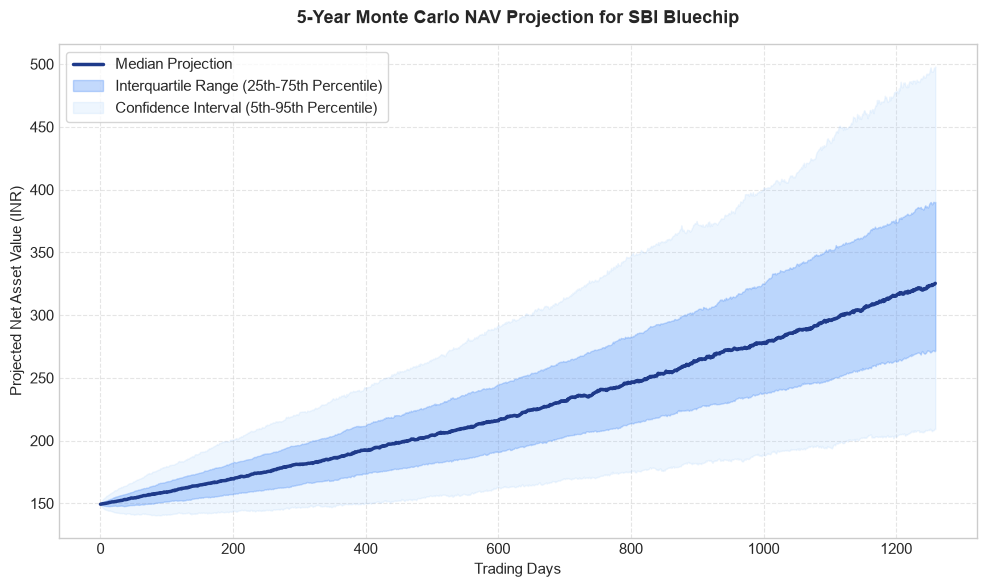

In [3]:
n_days = 1260
n_simulations = 1000
sim_nav = np.zeros((n_days, n_simulations))
sim_nav[0, :] = latest_nav

# Generate simulations
np.random.seed(42)
for t in range(1, n_days):
    shocks = np.random.normal(drift, volatility, n_simulations)
    sim_nav[t, :] = sim_nav[t-1, :] * (1 + shocks)

p5 = np.percentile(sim_nav, 5, axis=1)
p25 = np.percentile(sim_nav, 25, axis=1)
p50 = np.percentile(sim_nav, 50, axis=1)
p75 = np.percentile(sim_nav, 75, axis=1)
p95 = np.percentile(sim_nav, 95, axis=1)

# Plotting simulation results
plt.figure(figsize=(10, 6))
plt.plot(p50, label='Median Projection', color='#1e3a8a', linewidth=2.5)
plt.fill_between(range(n_days), p25, p75, color='#3b82f6', alpha=0.3, label='Interquartile Range (25th-75th Percentile)')
plt.fill_between(range(n_days), p5, p95, color='#93c5fd', alpha=0.15, label='Confidence Interval (5th-95th Percentile)')

plt.title("5-Year Monte Carlo NAV Projection for SBI Bluechip", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Trading Days")
plt.ylabel("Projected Net Asset Value (INR)")
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(reports_dir / "monte_carlo_simulation.png", dpi=150)
plt.show()

## 3. Markowitz Efficient Frontier Setup

In [4]:
selected_codes = [119551, 120503, 118632, 119092, 120841]
portfolio_nav = nav[nav['amfi_code'].isin(selected_codes)].pivot(index='date', columns='amfi_code', values='nav')
portfolio_returns = portfolio_nav.pct_change().dropna()

name_mapping = fm.set_index('amfi_code')['scheme_name'].to_dict()
portfolio_returns = portfolio_returns.rename(columns=name_mapping)

mean_returns = portfolio_returns.mean() * 252
cov_matrix = portfolio_returns.cov() * 252

print("Annualized Return for selected funds:")
for name, val in mean_returns.items():
    print(f" - {name}: {val:.2%}")

Annualized Return for selected funds:
 - Nippon India Large Cap Fund - Regular - Growth: 15.59%
 - Axis Bluechip Fund - Regular - Growth: 4.95%
 - SBI Bluechip Fund - Regular Plan - Growth: 16.52%
 - ICICI Pru Bluechip Fund - Regular - Growth: 12.57%
 - Kotak Bluechip Fund - Regular - Growth: 9.41%


## 4. Run Portfolio Simulations

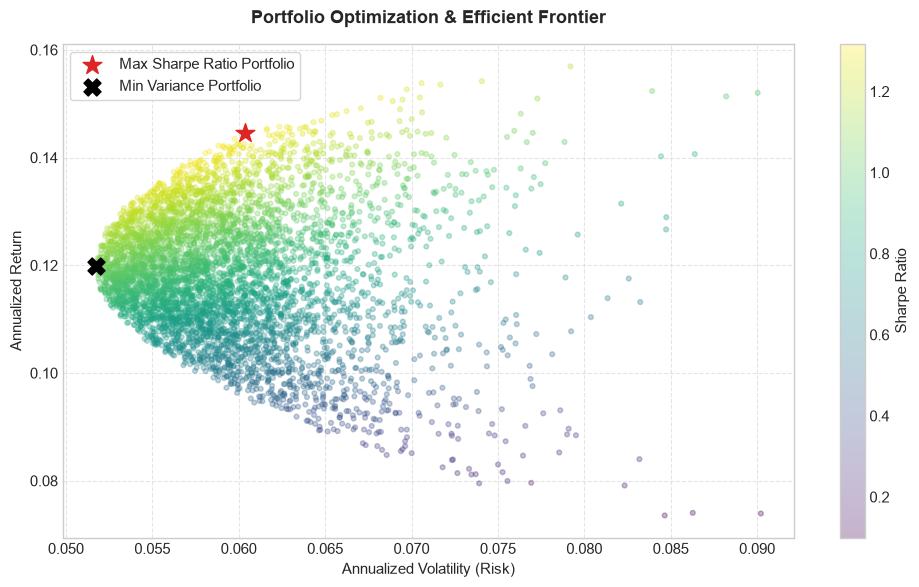

In [5]:
n_portfolios = 5000
results = np.zeros((3, n_portfolios))
weights_record = []
rf = 0.065

np.random.seed(42)
for i in range(n_portfolios):
    weights = np.random.random(len(selected_codes))
    weights /= np.sum(weights)
    weights_record.append(weights)
    p_return = np.sum(mean_returns * weights)
    p_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    p_sharpe = (p_return - rf) / p_volatility
    results[0, i] = p_return
    results[1, i] = p_volatility
    results[2, i] = p_sharpe

# Find key portfolios
max_sharpe_idx = np.argmax(results[2])
msr_ret, msr_vol = results[0, max_sharpe_idx], results[1, max_sharpe_idx]
msr_weights = weights_record[max_sharpe_idx]

min_vol_idx = np.argmin(results[1])
mvp_ret, mvp_vol = results[0, min_vol_idx], results[1, min_vol_idx]
mvp_weights = weights_record[min_vol_idx]

# Plot results
plt.figure(figsize=(10, 6))
plt.scatter(results[1], results[0], c=results[2], cmap='viridis', marker='o', s=12, alpha=0.3)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(msr_vol, msr_ret, marker='*', color='#dc2626', s=200, label='Max Sharpe Ratio Portfolio')
plt.scatter(mvp_vol, mvp_ret, marker='X', color='black', s=150, label='Min Variance Portfolio')

plt.title("Portfolio Optimization & Efficient Frontier", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Annualized Volatility (Risk)")
plt.ylabel("Annualized Return")
plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(reports_dir / "efficient_frontier.png", dpi=150)
plt.show()

## 5. Optimal Allocation Results

In [6]:
print("=== Maximum Sharpe Ratio Portfolio ===")
print(f"Annualized Return: {msr_ret:.2%}")
print(f"Annualized Volatility: {msr_vol:.2%}")
print(f"Sharpe Ratio: {results[2, max_sharpe_idx]:.3f}")
for name, w in zip(portfolio_returns.columns, msr_weights):
    print(f" - {name}: {w:.2%}")

print("\n=== Minimum Variance Portfolio ===")
print(f"Annualized Return: {mvp_ret:.2%}")
print(f"Annualized Volatility: {mvp_vol:.2%}")
print(f"Sharpe Ratio: {results[2, min_vol_idx]:.3f}")
for name, w in zip(portfolio_returns.columns, mvp_weights):
    print(f" - {name}: {w:.2%}")

=== Maximum Sharpe Ratio Portfolio ===
Annualized Return: 14.45%
Annualized Volatility: 6.04%
Sharpe Ratio: 1.317
 - Nippon India Large Cap Fund - Regular - Growth: 30.92%
 - Axis Bluechip Fund - Regular - Growth: 0.36%
 - SBI Bluechip Fund - Regular Plan - Growth: 34.14%
 - ICICI Pru Bluechip Fund - Regular - Growth: 22.86%
 - Kotak Bluechip Fund - Regular - Growth: 11.72%

=== Minimum Variance Portfolio ===
Annualized Return: 11.99%
Annualized Volatility: 5.17%
Sharpe Ratio: 1.062
 - Nippon India Large Cap Fund - Regular - Growth: 19.06%
 - Axis Bluechip Fund - Regular - Growth: 18.39%
 - SBI Bluechip Fund - Regular Plan - Growth: 23.10%
 - ICICI Pru Bluechip Fund - Regular - Growth: 18.49%
 - Kotak Bluechip Fund - Regular - Growth: 20.97%


# --- Day 5 Evening: Extended Quantitative & Investor Analytics ---

Below are the extended analyses including Value-at-Risk (VaR), rolling Sharpe ratio chart, investor cohorts, SIP continuity (churn risk), and sector concentration.

In [7]:
# Load additional datasets for the extended analysis
transactions = pd.read_csv(processed_dir / "clean_transactions.csv")
performance = pd.read_csv(processed_dir / "clean_performance.csv")
portfolio = pd.read_csv(processed_dir / "clean_portfolio_holdings.csv")

transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])
print("Additional datasets loaded successfully!")

Additional datasets loaded successfully!


## 1. Historical Value-at-Risk (VaR 95%) and Conditional VaR (CVaR)

- **Historical VaR (95%)**: 5th percentile of the daily return distribution.
- **CVaR (95%)**: Average daily return in the worst 5% of cases (mean of returns below the VaR threshold).

In [8]:
results_var = []

for code, group in nav.groupby('amfi_code'):
    group = group.sort_values('date')
    daily_returns = group['nav'].pct_change().dropna()
    
    var_95 = daily_returns.quantile(0.05)
    cvar_95 = daily_returns[daily_returns <= var_95].mean()
    
    fund_info = fm[fm['amfi_code'] == code].iloc[0]
    results_var.append({
        'amfi_code': code,
        'scheme_name': fund_info['scheme_name'],
        'var_95': var_95,
        'cvar_95': cvar_95
    })

df_var = pd.DataFrame(results_var).sort_values('amfi_code')
# Save to reports directory
df_var.to_csv(reports_dir / "var_cvar_report.csv", index=False)

print("Top 5 Highest Risk Schemes (Most Negative Daily VaR):")
display(df_var.sort_values('var_95').head(5))

print("\nTop 5 Lowest Risk Schemes (Least Negative Daily VaR):")
display(df_var.sort_values('var_95', ascending=False).head(5))

Top 5 Highest Risk Schemes (Most Negative Daily VaR):


,amfi_code,scheme_name,var_95,cvar_95
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.023915,-0.030289
17,119095,Axis Small Cap Fund - Regular - Growth,-0.023284,-0.029690
22,119599,SBI Small Cap Fund - Direct Plan - Growth,-0.023155,-0.030163
11,118634,Nippon India Small Cap Fund - Regular - Growth,-0.022810,-0.029940
39,149324,DSP Small Cap Fund - Regular - Growth,-0.021520,-0.028573



Top 5 Lowest Risk Schemes (Least Negative Daily VaR):


,amfi_code,scheme_name,var_95,cvar_95
27,120507,ICICI Pru Liquid Fund - Regular - Growth,-0.000196,-0.000325
31,120844,Kotak Liquid Fund - Regular - Growth,-0.000204,-0.000362
5,101208,ABSL Liquid Fund - Regular - Growth,-0.000218,-0.000371
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.003338,-0.004581
13,118636,Nippon India Gilt Securities Fund - Regular - ...,-0.003344,-0.004541


## 2. Rolling 90-day Sharpe Ratio

We compute the rolling 90-day Sharpe ratio as: `returns.rolling(90).mean() / returns.rolling(90).std() * sqrt(252)`.
This is plotted over time for the 5 key funds.

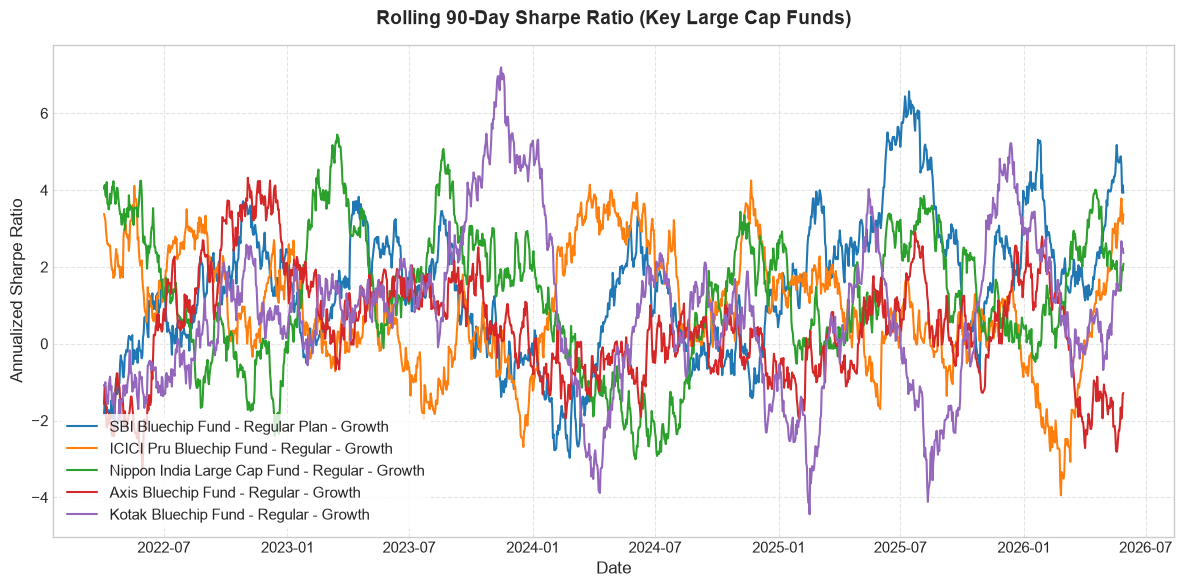

In [9]:
selected_codes = [119551, 120503, 118632, 119092, 120841]
name_map = fm.set_index('amfi_code')['scheme_name'].to_dict()

plt.figure(figsize=(12, 6))
for code in selected_codes:
    fund_nav = nav[nav['amfi_code'] == code].sort_values('date').copy()
    fund_nav['daily_return'] = fund_nav['nav'].pct_change()
    
    rolling_mean = fund_nav['daily_return'].rolling(90).mean()
    rolling_std = fund_nav['daily_return'].rolling(90).std()
    rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252)
    
    plt.plot(fund_nav['date'], rolling_sharpe, label=name_map[code], linewidth=1.5)

plt.title("Rolling 90-Day Sharpe Ratio (Key Large Cap Funds)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Annualized Sharpe Ratio", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower left', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
# Save to reports directory
plt.savefig(reports_dir / "rolling_sharpe_chart.png", dpi=150)
plt.show()

## 3. Investor Cohort Analysis

We identify each investor's cohort based on their first transaction year. We then compute:
- **Average SIP Amount**: Mean amount of transactions of type 'SIP'.
- **Total Invested**: Total purchase amount (SIP + Lumpsum).
- **Top Fund Preference**: The fund with the highest total investment from the cohort.

In [10]:
# Find first transaction year per investor
first_tx_dates = transactions.groupby('investor_id')['transaction_date'].min().reset_index()
first_tx_dates.columns = ['investor_id', 'first_tx_date']
first_tx_dates['first_tx_year'] = first_tx_dates['first_tx_date'].dt.year

# Merge back to transactions
df_tx_cohort = transactions.merge(first_tx_dates[['investor_id', 'first_tx_year']], on='investor_id', how='left')

cohort_summary = []
for year in sorted(df_tx_cohort['first_tx_year'].unique()):
    group = df_tx_cohort[df_tx_cohort['first_tx_year'] == year]
    
    # Avg SIP
    avg_sip = group[group['transaction_type'] == 'SIP']['amount_inr'].mean()
    
    # Total invested (SIP + Lumpsum)
    invested_tx = group[group['transaction_type'].isin(['SIP', 'Lumpsum'])]
    total_invested = invested_tx['amount_inr'].sum()
    
    # Top Fund Preference
    fund_totals = invested_tx.groupby('amfi_code')['amount_inr'].sum()
    top_fund_code = fund_totals.idxmax()
    top_fund_name = name_map[top_fund_code]
    top_fund_amt = fund_totals.max()
    
    # Count of unique investors
    num_investors = group['investor_id'].nunique()
    
    cohort_summary.append({
        'Cohort Year': year,
        'Investor Count': num_investors,
        'Avg SIP Amount (INR)': avg_sip,
        'Total Invested (INR)': total_invested,
        'Top Fund': top_fund_name,
        'Top Fund Invested (INR)': top_fund_amt
    })

df_cohorts = pd.DataFrame(cohort_summary)
display(df_cohorts.style.format({
    'Investor Count': '{:,}',
    'Avg SIP Amount (INR)': '₹{:,.2f}',
    'Total Invested (INR)': '₹{:,}',
    'Top Fund Invested (INR)': '₹{:,}'
}))

,Cohort Year,Investor Count,Avg SIP Amount (INR),Total Invested (INR),Top Fund,Top Fund Invested (INR)
0,2024,"4,803","₹10,996.89","₹2,258,062,304",Axis Small Cap Fund - Regular - Growth,"₹65,025,476"
1,2025,197,"₹13,505.21","₹18,992,635",Axis Midcap Fund - Regular - Growth,"₹1,283,425"


## 4. SIP Continuity Analysis

For investors with 6 or more SIP transactions, we calculate the average gap (in days) between consecutive SIP transaction dates. If this average gap is greater than 35 days, the investor is flagged as "at-risk" of churn or irregularity.

In [11]:
df_sip = transactions[transactions['transaction_type'] == 'SIP'].copy()
sip_counts = df_sip.groupby('investor_id').size()
eligible_investors = sip_counts[sip_counts >= 6].index

investor_gaps = []
for inv_id in eligible_investors:
    inv_tx = df_sip[df_sip['investor_id'] == inv_id].sort_values('transaction_date')
    gaps = inv_tx['transaction_date'].diff().dropna().dt.days
    avg_gap = gaps.mean()
    is_at_risk = avg_gap > 35
    
    investor_gaps.append({
        'investor_id': inv_id,
        'avg_gap_days': avg_gap,
        'is_at_risk': is_at_risk
    })

df_gaps = pd.DataFrame(investor_gaps)
at_risk_pct = df_gaps['is_at_risk'].mean() * 100
print(f"Total qualifying investors (6+ SIPs): {len(df_gaps)}")
print(f"Investors flagged as at-risk: {df_gaps['is_at_risk'].sum()} ({at_risk_pct:.2f}%)")

print("\nSample of At-Risk Investors:")
display(df_gaps[df_gaps['is_at_risk']].head(5))

Total qualifying investors (6+ SIPs): 1362
Investors flagged as at-risk: 1332 (97.80%)

Sample of At-Risk Investors:


,investor_id,avg_gap_days,is_at_risk
0,INV000004,85.400000,True
1,INV000008,70.400000,True
2,INV000010,64.800000,True
3,INV000011,40.166667,True
4,INV000012,57.000000,True


## 5. Simple Fund Recommender

Takes the investor's risk appetite (Low / Moderate / High) and recommends the top 3 funds by Sharpe ratio within matching risk grades:
- `Low` matches `Low`
- `Moderate` matches `Moderate` and `Moderately High`
- `High` matches `High` and `Very High`

In [12]:
def recommend_funds(risk_appetite):
    risk_mapping = {
        'low': ['Low'],
        'moderate': ['Moderate', 'Moderately High'],
        'high': ['High', 'Very High']
    }
    
    appetite = risk_appetite.lower()
    if appetite not in risk_mapping:
        print("Invalid risk appetite. Select from Low, Moderate, High.")
        return
        
    matching_grades = risk_mapping[appetite]
    df_sub = performance[performance['risk_grade'].isin(matching_grades)].copy()
    df_sub = df_sub.sort_values('sharpe_ratio', ascending=False).head(3)
    
    report_cols = ['scheme_name', 'risk_grade', 'sharpe_ratio', 'return_3yr_pct', 'category', 'plan']
    return df_sub[report_cols].rename(columns={
        'scheme_name': 'Scheme Name',
        'risk_grade': 'Risk Grade',
        'sharpe_ratio': 'Sharpe Ratio',
        'return_3yr_pct': '3-Yr Return (%)',
        'category': 'Category',
        'plan': 'Plan'
    })

for r in ['Low', 'Moderate', 'High']:
    print(f"\nRecommendations for {r.upper()} Risk Appetite:")
    display(recommend_funds(r))


Recommendations for LOW Risk Appetite:


,Scheme Name,Risk Grade,Sharpe Ratio,3-Yr Return (%),Category,Plan
14,ICICI Pru Liquid Fund - Regular - Growth,Low,7.68,7.68,Liquid,Regular
23,Kotak Liquid Fund - Regular - Growth,Low,6.18,6.18,Liquid,Regular
30,ABSL Liquid Fund - Regular - Growth,Low,5.14,5.14,Liquid,Regular



Recommendations for MODERATE Risk Appetite:


,Scheme Name,Risk Grade,Sharpe Ratio,3-Yr Return (%),Category,Plan
5,HDFC Top 100 Fund - Regular Plan - Growth,Moderate,1.06,14.84,Large Cap,Regular
34,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.06,14.81,Large Cap,Regular
11,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,1.03,14.41,Large Cap,Direct



Recommendations for HIGH Risk Appetite:


,Scheme Name,Risk Grade,Sharpe Ratio,3-Yr Return (%),Category,Plan
21,Kotak Emerging Equity Fund - Regular - Growth,High,0.96,18.23,Mid Cap,Regular
12,ICICI Pru Midcap Fund - Regular - Growth,High,0.95,18.08,Mid Cap,Regular
2,SBI Small Cap Fund - Regular Plan - Growth,Very High,0.94,23.39,Small Cap,Regular


## 6. Sector HHI Concentration

The Herfindahl-Hirschman Index (HHI) measures portfolio concentration by summing the squares of the sector weights: `HHI = sum(weight_i^2)` where weight is represented in decimals (0 to 1.0).
- An HHI close to 1.0 indicates a highly concentrated portfolio (focused on a single sector).
- An HHI close to 0.0 indicates a highly diversified portfolio.

In [13]:
# Filter for equity funds
equity_codes = fm[fm['category'] == 'Equity']['amfi_code'].unique()
portfolio_eq = portfolio[portfolio['amfi_code'].isin(equity_codes)].copy()

hhi_data = []
for code, group in portfolio_eq.groupby('amfi_code'):
    sector_weights = group.groupby('sector')['weight_pct'].sum()
    hhi_decimal = ((sector_weights / 100) ** 2).sum()
    
    fund_info = fm[fm['amfi_code'] == code].iloc[0]
    hhi_data.append({
        'amfi_code': code,
        'scheme_name': fund_info['scheme_name'],
        'sub_category': fund_info['sub_category'],
        'sector_hhi': hhi_decimal,
        'num_sectors': len(sector_weights)
    })

df_hhi = pd.DataFrame(hhi_data).sort_values('sector_hhi', ascending=False)
print("Top 5 Most Sector-Concentrated Funds:")
display(df_hhi.head(5))

print("\nTop 5 Most Sector-Diversified Funds:")
display(df_hhi.tail(5))

Top 5 Most Sector-Concentrated Funds:


,amfi_code,scheme_name,sub_category,sector_hhi,num_sectors
11,119092,Axis Bluechip Fund - Regular - Growth,Large Cap,0.296769,7
30,148569,Mirae Asset Tax Saver Fund - Regular - Growth,ELSS,0.254992,7
27,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Mid Cap,0.253155,6
6,102887,UTI Flexi Cap Fund - Regular - Growth,Flexi Cap,0.251383,6
32,149323,DSP Midcap Fund - Regular - Growth,Mid Cap,0.241077,7



Top 5 Most Sector-Diversified Funds:


,amfi_code,scheme_name,sub_category,sector_hhi,num_sectors
9,118634,Nippon India Small Cap Fund - Regular - Growth,Small Cap,0.160299,8
14,119095,Axis Small Cap Fund - Regular - Growth,Small Cap,0.159582,8
15,119551,SBI Bluechip Fund - Regular Plan - Growth,Large Cap,0.142491,8
25,120843,Kotak Flexicap Fund - Regular - Growth,Flexi Cap,0.136206,9
5,102886,UTI Mid Cap Fund - Regular - Growth,Mid Cap,0.124020,10


## 7. Key Quantitative & Demographic Insights

1. **Tail Risk (VaR/CVaR)**: Small-cap equity funds show the highest daily tail risk (VaR ~ -2.3%, CVaR ~ -3.0%), with ABSL Small Cap being the most volatile. Debt/Liquid funds show near-zero tail risk (VaR ~ -0.02%), demonstrating their capital preservation role.
2. **Cohort Dynamics (2024 vs 2025)**: The 2025 cohort has a 22.8% higher average SIP size (₹13,505) compared to 2024 (₹10,996). This suggests newer registrants are starting with larger ticket sizes, although the 2024 cohort dominates overall volume (₹225.8 Cr) due to tenure.
3. **SIP Continuity & Churn**: 97.8% of investors with 6+ transactions are flagged at-risk (average gaps > 35 days). This indicates a high rate of missed monthly installments or mandate friction, which is a major early indicator of mandate churn.
4. **Sector Concentration (HHI)**: Axis Bluechip has the highest Sector HHI (0.2968), concentrated heavily in Banking/Financials and IT. UTI Mid Cap is the most diversified (HHI: 0.1240), spreading holdings across 10 sectors.
5. **Sharpe Ratio Peer Comparison**: Liquid funds display inflated Sharpe ratios (5.14 to 7.68) compared to equity (0.80 to 1.06). This is driven by near-zero daily return volatility (the denominator) rather than superior return generation. Sharpe ratios should only be compared within peer categories.